# Avaliação Parcial 1 - EfficientNevV2 S

Esse notebook contém a implementação de uma CNN com a arquitetura EfficientNetV2 S utilizando Transfer Learning

## Importação dos módulos

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import os
import csv
from tqdm import tqdm
from pathlib import Path
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Transforms

In [7]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

## Carregando o dataset

In [6]:
path = "data"

In [8]:
train_path = os.path.join(path, "train")

full_dataset = datasets.ImageFolder(train_path, transform=train_transforms)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = test_transforms

In [9]:
test_path = os.path.join(path, "test")

test_dataset = datasets.ImageFolder(test_path, transform=test_transforms)

## Dataloaders

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader  = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True)

classes = full_dataset.classes
num_classes = len(classes)

print("Classes:", num_classes)

Classes: 120


## Modelo

In [11]:
model = models.efficientnet_v2_s(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

/home/pcmi/miniconda3/envs/topicos1/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/pcmi/miniconda3/envs/topicos1/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params: 20,331,208
Trainable params: 153,720


## Configuração do treino

In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4  # L2 regularization
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.3
)

In [15]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

early_stopping = EarlyStopping(patience=5)

## Treino e validação

In [16]:
os.makedirs("models", exist_ok=True)

EPOCHS = 30

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_model = copy.deepcopy(model.state_dict())
best_loss = np.inf

start_time = time.time()

In [17]:
for epoch in range(EPOCHS):

    model.train()
    train_loss, correct, total = 0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [TRAIN]")

    for batch_idx, (images, labels) in enumerate(pbar):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        #print("Batch:", images.device, labels.device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

        acc = correct / total

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{acc:.4f}",
            "batch": f"{batch_idx+1}/{len(train_loader)}"
        })

    train_loss /= len(train_loader)
    train_acc = correct / total

    model.eval()
    val_loss, correct, total = 0, 0, 0

    vbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [VAL]")

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(vbar):

            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            acc = correct / total

            vbar.set_postfix({
                "val_loss": f"{loss.item():.4f}",
                "val_acc": f"{acc:.4f}"
            })

    val_loss /= len(val_loader)
    val_acc = correct / total

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}\n")

    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "models/best_model.pth")

    if early_stopping.step(val_loss):
        print("Early stopping!")
        break

Epoch 1/30 [VAL]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:04<00:00, 16.76it/s, val_loss=0.7672, val_acc=0.7778]



Epoch 1: Train Acc=0.6080 | Val Acc=0.7778



Epoch 2/30 [VAL]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:03<00:00, 17.52it/s, val_loss=0.5585, val_acc=0.7954]



Epoch 2: Train Acc=0.7846 | Val Acc=0.7954



Epoch 3/30 [VAL]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:03<00:00, 17.77it/s, val_loss=0.7004, val_acc=0.7833]


...


Epoch 9: Train Acc=0.8851 | Val Acc=0.7880



Epoch 10/30 [VAL]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:03<00:00, 17.53it/s, val_loss=0.6949, val_acc=0.7806]



Epoch 10: Train Acc=0.8892 | Val Acc=0.7806



Epoch 11/30 [VAL]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [00:03<00:00, 17.12it/s, val_loss=0.7369, val_acc=0.7907]


Epoch 11: Train Acc=0.9047 | Val Acc=0.7907

Early stopping!


In [19]:
results_dir = Path("results")

In [8]:
results_dir.mkdir(parents=True, exist_ok=True)

csv_path = results_dir / "cnn_training_history.csv"

with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["epoch", "train_loss", "val_loss", "train_acc", "val_acc"])
    for epoch_index, (train_loss_value, val_loss_value, train_acc_value, val_acc_value) in enumerate(
        zip(
            history["train_loss"],
            history["val_loss"],
            history["train_acc"],
            history["val_acc"],
        ), start=1
    ):
        writer.writerow([
            epoch_index,
            train_loss_value,
            val_loss_value,
            train_acc_value,
            val_acc_value,
        ])

print(f"Histórico salvo em: {csv_path}")

NameError: name 'history' is not defined

In [18]:
start = time.time()

for i, (images, labels) in enumerate(train_loader):
    if i == 50:
        break

print("Tempo DataLoader:", time.time() - start)

Tempo DataLoader: 0.7913248538970947


In [20]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

start = time.time()

for _ in range(50):
    outputs = model(images)

print("Tempo GPU:", time.time() - start)

Tempo GPU: 2.618802070617676


## Teste

In [13]:
model = models.efficientnet_v2_s(pretrained=False)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model.load_state_dict(torch.load("models/best_model.pth", map_location=device, weights_only=True))

model = model.to(device)
model.eval()

print("Modelo carregado com sucesso.")

/home/pcmi/miniconda3/envs/topicos1/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Modelo carregado com sucesso.


In [14]:
criterion = nn.CrossEntropyLoss()

def evaluate_model(model, loader, criterion):
    """Avalia o modelo no conjunto de teste.
    Retorna: loss média, acurácia, lista de predições e lista de rótulos reais.
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels

In [15]:
print("Iniciando avaliação no conjunto de teste...")
start = time.time()

test_loss, test_acc, preds, labels = evaluate_model(model, test_loader, criterion)

elapsed = time.time() - start
print(f"\nResultados no Teste:")
print(f"  Loss     : {test_loss:.4f}")
print(f"  Acurácia : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Tempo    : {elapsed:.2f} segundos")

Iniciando avaliação no conjunto de teste...

Resultados no Teste:
  Loss     : 0.7600
  Acurácia : 0.8131 (81.31%)
  Tempo    : 24.09 segundos


In [18]:
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_file = results_dir / "test_metrics.txt"
with open(metrics_file, "w", encoding="utf-8") as f:
    f.write(f"Loss no teste: {test_loss:.4f}\n")
    f.write(f"Acurácia no teste: {test_acc:.4f} ({test_acc*100:.2f}%)\n\n")
    f.write("Relatório de Classificação:\n")
    f.write(report)
print(f"Métricas salvas em: {metrics_file}")

Métricas salvas em: results/test_metrics.txt


## Resultados e Gráficos

Dados carregados:
   epoch  train_loss  val_loss  train_acc   val_acc
0      1    2.146705  1.057601   0.607986  0.777778
1      2    0.891825  0.776575   0.784606  0.795370
2      3    0.708210  0.741493   0.812153  0.783333
3      4    0.608831  0.707269   0.833565  0.794907
4      5    0.552000  0.709821   0.847222  0.785648


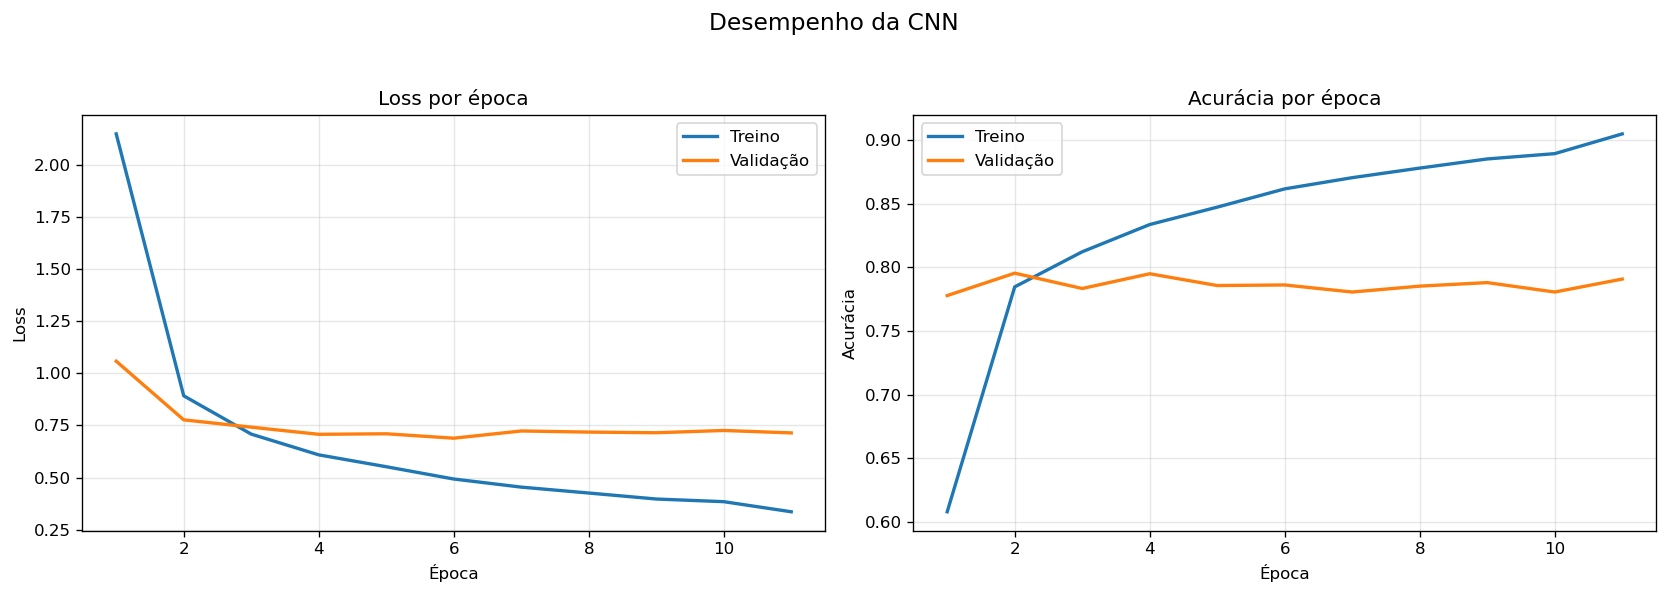

Gráfico salvo em: results/cnn_training_curves.png


In [24]:
csv_path = Path("results/cnn_training_history.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {csv_path}. Execute o treinamento primeiro.")

df = pd.read_csv(csv_path)

print("Dados carregados:")
print(df.head())

epochs = df["epoch"]
train_loss = df["train_loss"]
val_loss = df["val_loss"]
train_acc = df["train_acc"]
val_acc = df["val_acc"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

axes[0].plot(epochs, train_loss, label="Treino", linewidth=2)
axes[0].plot(epochs, val_loss, label="Validação", linewidth=2)
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, train_acc, label="Treino", linewidth=2)
axes[1].plot(epochs, val_acc, label="Validação", linewidth=2)
axes[1].set_title("Acurácia por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle("Desempenho da CNN", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plot_path = Path("results/cnn_training_curves.png")
fig.savefig(plot_path, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo em: {plot_path}")

In [16]:
report = classification_report(labels, preds, target_names=classes, digits=4)
print("Relatório de Classificação:")
print(report)

Relatório de Classificação:
                                precision    recall  f1-score   support

                  Afghan_hound     0.9562    0.9424    0.9493       139
           African_hunting_dog     0.9452    1.0000    0.9718        69
                      Airedale     0.8476    0.8725    0.8599       102
American_Staffordshire_terrier     0.7091    0.6094    0.6555        64
                   Appenzeller     0.6591    0.5686    0.6105        51
            Australian_terrier     0.7708    0.7708    0.7708        96
            Bedlington_terrier     0.9390    0.9390    0.9390        82
          Bernese_mountain_dog     0.9292    0.8898    0.9091       118
              Blenheim_spaniel     0.9529    0.9205    0.9364        88
                 Border_collie     0.7037    0.7600    0.7308        50
                Border_terrier     0.9231    0.8333    0.8759        72
                   Boston_bull     0.8831    0.8293    0.8553        82
          Bouvier_des_Flandres     

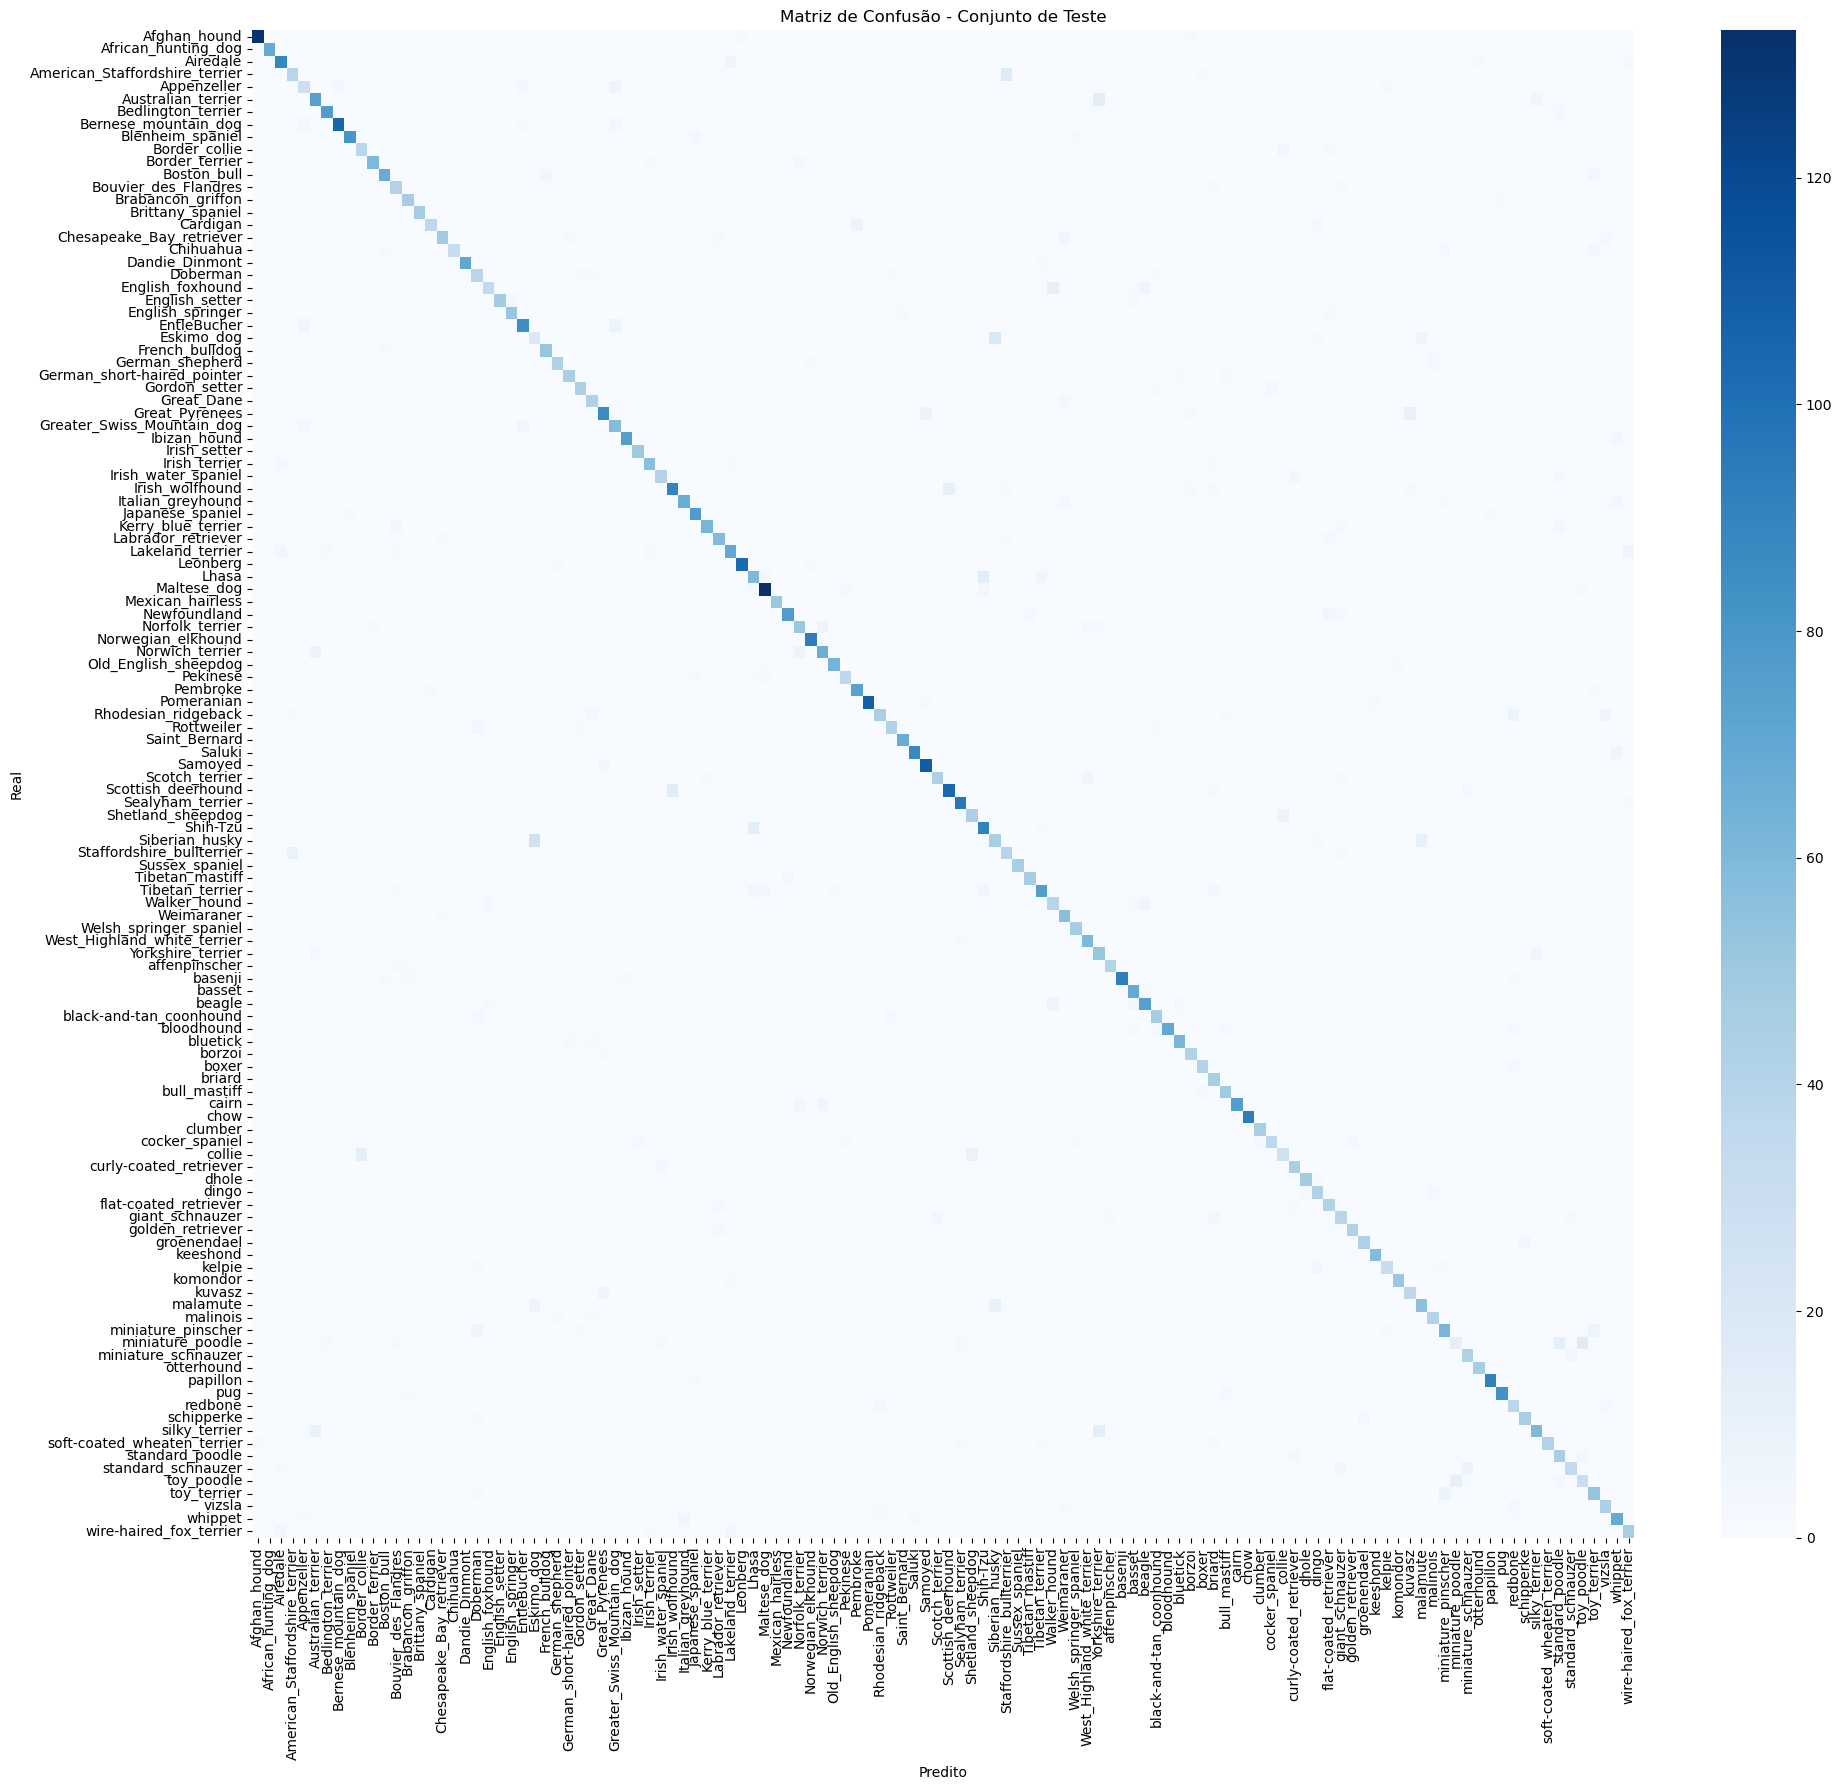

Matriz de confusão salva em: results/confusion_matrix_test.png


In [17]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plot_path = Path("results") / "confusion_matrix_test.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Matriz de confusão salva em: {plot_path}")

## Inferência

In [29]:
image_path = "cachorro.webp"

img = Image.open(image_path).convert("RGB")
img_tensor = test_transforms(img).unsqueeze(0)     

img_tensor = img_tensor.to(device)

model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    probabilities = F.softmax(outputs, dim=1)

conf, pred_idx = torch.max(probabilities, 1)
pred_class = classes[pred_idx.item()]
confidence = conf.item()

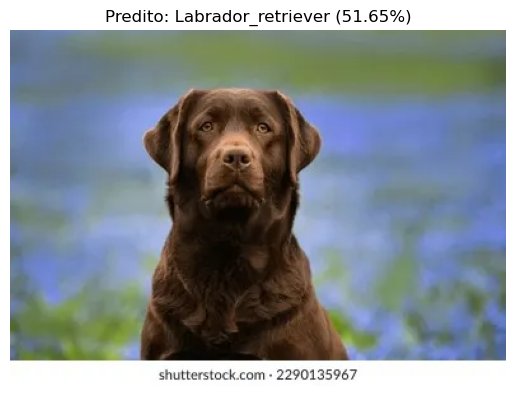

Classe predita: Labrador_retriever
Confiança: 0.5165 (51.65%)

Top‑5 predições:
  Labrador_retriever: 51.65%
  Chesapeake_Bay_retriever: 23.39%
  vizsla: 4.84%
  Great_Dane: 3.52%
  German_short-haired_pointer: 3.18%


In [30]:
plt.imshow(img)
plt.axis("off")
plt.title(f"Predito: {pred_class} ({confidence*100:.2f}%)")
plt.show()

print(f"Classe predita: {pred_class}")
print(f"Confiança: {confidence:.4f} ({confidence*100:.2f}%)")

top5_prob, top5_idx = torch.topk(probabilities, 5)
print("\nTop‑5 predições:")
for i in range(5):
    print(f"  {classes[top5_idx[0][i]]}: {top5_prob[0][i]*100:.2f}%")